# Employee Turnover Analytics — Portobello Tech

**Company:** Portobello Tech  
**Dataset:** `HR_comma_sep.csv`  
**Author:** Nicholas D'Angelo  
**Date:** April 2026  

---

## Objective

Portobello Tech periodically evaluates employees' work details — number of projects, average monthly working hours, tenure, promotions, and salary level — to predict employee turnover.

This notebook covers six key stages:
1. **Data Quality Checks** – missing-value inspection  
2. **Exploratory Data Analysis (EDA)** – correlations, distributions, project counts  
3. **Clustering** – K-Means on employees who left (satisfaction × evaluation)  
4. **Class-Imbalance Handling** – SMOTE upsampling  
5. **Model Training & Cross-Validation** – Logistic Regression, Random Forest, Gradient Boosting  
6. **Retention Strategy** – risk-zone categorisation and recommendations

---
## 0. Setup – Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

print('pandas :', pd.__version__)
print('numpy  :', np.__version__)
print('seaborn:', sns.__version__)
import sklearn; print('sklearn:', sklearn.__version__)
import imblearn; print('imblearn:', imblearn.__version__)


pandas : 3.0.2
numpy  : 2.4.4
seaborn: 0.13.2
sklearn: 1.8.0
imblearn: 0.14.1


---
## 1. Data Quality Checks

### 1.1 Load the Raw Data

In [2]:
df_raw = pd.read_csv('HR_comma_sep.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head(10)


Shape: (14999, 10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


### 1.2 Missing-Value Check

In [4]:
print('=== Missing values per column ===')
missing = df_raw.isnull().sum()
print(missing)
print(f'\nTotal missing cells: {missing.sum()}')


=== Missing values per column ===
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

Total missing cells: 0


In [5]:
df_raw.describe()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


**Finding:** The dataset contains **no missing values** across all 14,999 rows and 10 columns.  
All numeric columns are within plausible ranges (e.g., satisfaction_level and last_evaluation lie in [0, 1]).  
No data-cleaning or imputation steps are required before modelling.

---
## 2. Exploratory Data Analysis (EDA)

In [6]:
df = df_raw.copy()
print('Class balance (left):')
print(df['left'].value_counts())
print(f'\nTurnover rate: {df["left"].mean()*100:.1f}%')


Class balance (left):
left
0    11428
1     3571
Name: count, dtype: int64

Turnover rate: 23.8%


### 2.1 Correlation Heatmap

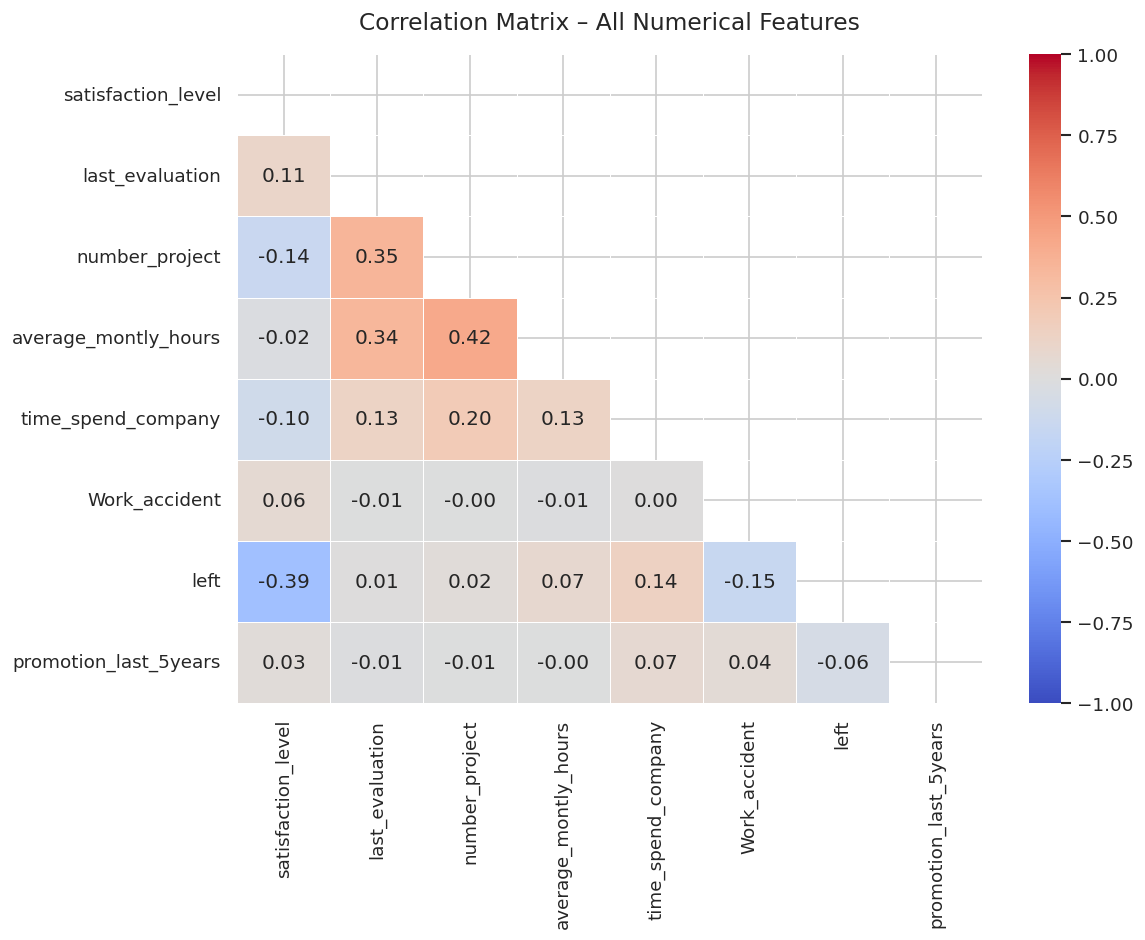

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix – All Numerical Features', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


**Key Observations:**  
- `satisfaction_level` has a **strong negative correlation** with `left` (−0.39) — lower satisfaction strongly predicts departure.  
- `number_project` and `average_montly_hours` are highly positively correlated (+0.42), as more projects naturally demand more hours.  
- `time_spend_company` shows a moderate positive correlation with `left` (+0.14) — longer-tenured employees are somewhat more likely to leave.

### 2.2 Distribution Plots

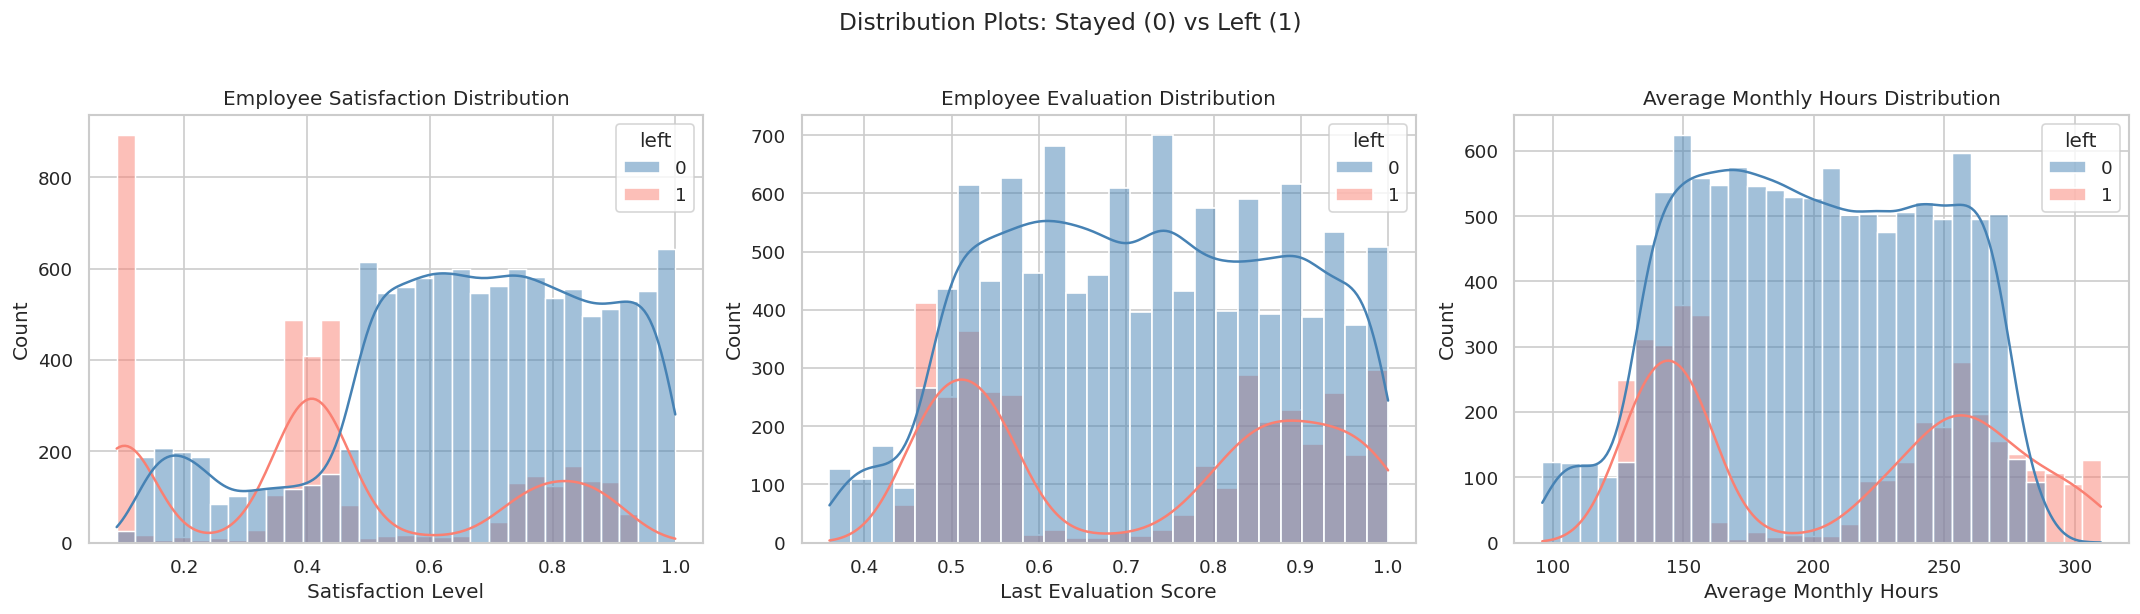

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df, x='satisfaction_level', hue='left', kde=True, ax=axes[0],
             palette={0: 'steelblue', 1: 'salmon'})
axes[0].set_title('Employee Satisfaction Distribution')
axes[0].set_xlabel('Satisfaction Level')

sns.histplot(df, x='last_evaluation', hue='left', kde=True, ax=axes[1],
             palette={0: 'steelblue', 1: 'salmon'})
axes[1].set_title('Employee Evaluation Distribution')
axes[1].set_xlabel('Last Evaluation Score')

sns.histplot(df, x='average_montly_hours', hue='left', kde=True, ax=axes[2],
             palette={0: 'steelblue', 1: 'salmon'})
axes[2].set_title('Average Monthly Hours Distribution')
axes[2].set_xlabel('Average Monthly Hours')

plt.suptitle('Distribution Plots: Stayed (0) vs Left (1)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Key Observations:**  
- **Satisfaction Level:** Employees who left cluster into two groups — a very dissatisfied group (score ~0.1) and a moderately satisfied group (~0.7). Very few highly satisfied employees (>0.8) left.  
- **Last Evaluation:** Employees who left tend to have either very low (<0.5) or very high (>0.8) evaluation scores, suggesting both underperformers and overachievers leave.  
- **Average Monthly Hours:** Departing employees worked either very few (~150 hrs) or very many (~250–310 hrs) hours per month, indicating disengagement or burnout as key drivers.

### 2.3 Bar Plot – Project Count vs Turnover

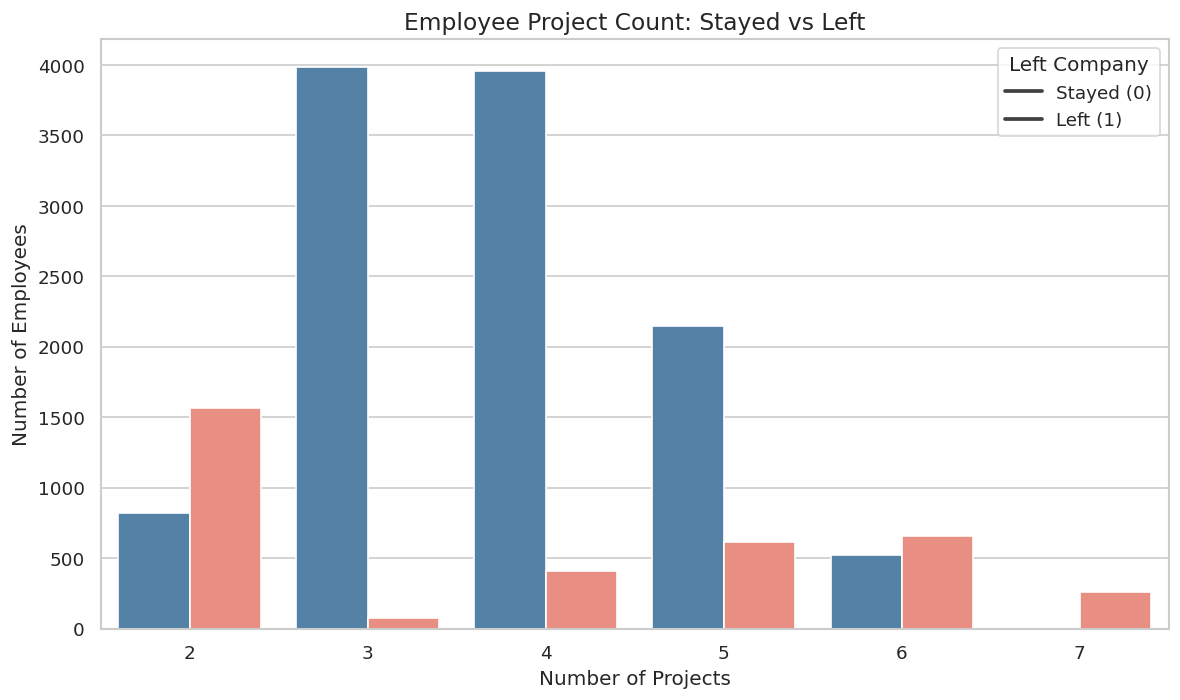

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
project_counts = (df.groupby(['number_project', 'left'])
                    .size()
                    .reset_index(name='count'))
sns.barplot(data=project_counts, x='number_project', y='count',
            hue='left', palette={0: 'steelblue', 1: 'salmon'}, ax=ax)
ax.set_title('Employee Project Count: Stayed vs Left', fontsize=14)
ax.set_xlabel('Number of Projects')
ax.set_ylabel('Number of Employees')
ax.legend(title='Left Company', labels=['Stayed (0)', 'Left (1)'])
plt.tight_layout()
plt.show()


**Inferences from the Project Count Bar Plot:**  
- Employees assigned **2 projects** account for the largest single group that left — possibly due to underutilisation / disengagement.  
- Employees with **6 or 7 projects** have a very high turnover rate relative to those who stayed — consistent with burnout from overwork.  
- The **3–4 project sweet spot** shows the healthiest retention, with more employees staying than leaving.  
- **Action:** Aim to keep project loads in the 3–4 range; flag employees with ≤2 or ≥6 active projects for managerial check-ins.

---
## 3. Clustering of Employees Who Left

### 3.1 Prepare the Subset

In [10]:
df_left = df[df['left'] == 1][['satisfaction_level', 'last_evaluation', 'left']].copy()
print(f'Employees who left: {len(df_left)}')
df_left.head()


Employees who left: 3571


,satisfaction_level,last_evaluation,left
0,0.38,0.53,1
1,0.80,0.86,1
2,0.11,0.88,1
3,0.72,0.87,1
4,0.37,0.52,1


### 3.2 K-Means Clustering (k = 3)

In [11]:
X_cluster = df_left[['satisfaction_level', 'last_evaluation']].values

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_left = df_left.copy()
df_left['cluster'] = kmeans.fit_predict(X_cluster)

print('Cluster sizes:')
print(df_left['cluster'].value_counts().sort_index())
print('\nCluster centres (satisfaction, evaluation):')
for i, c in enumerate(kmeans.cluster_centers_):
    print(f'  Cluster {i}: satisfaction={c[0]:.3f}, evaluation={c[1]:.3f}')


Cluster sizes:
cluster
0    1650
1     977
2     944
Name: count, dtype: int64

Cluster centres (satisfaction, evaluation):
  Cluster 0: satisfaction=0.410, evaluation=0.517
  Cluster 1: satisfaction=0.809, evaluation=0.912
  Cluster 2: satisfaction=0.111, evaluation=0.869


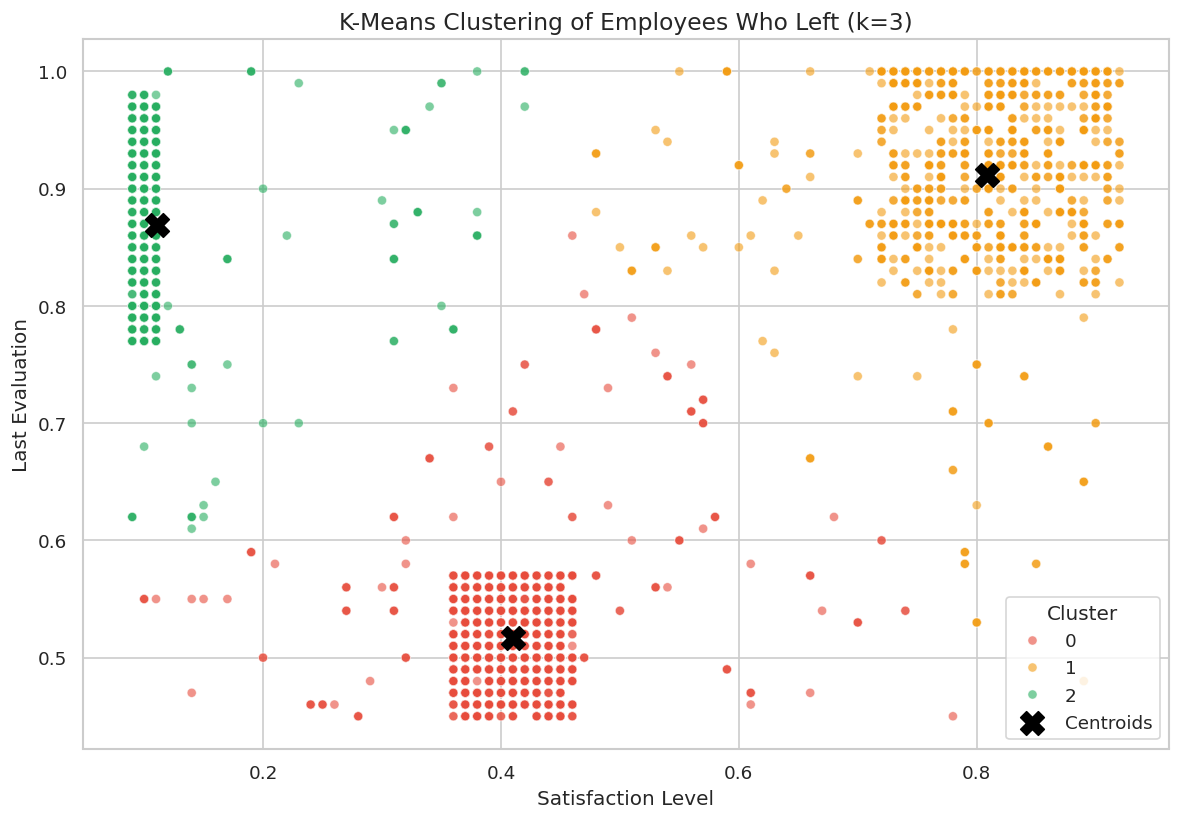

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))
palette = {0: '#e74c3c', 1: '#f39c12', 2: '#27ae60'}
sns.scatterplot(
    data=df_left, x='satisfaction_level', y='last_evaluation',
    hue='cluster', palette=palette, alpha=0.6, s=30, ax=ax
)
centres = kmeans.cluster_centers_
ax.scatter(centres[:, 0], centres[:, 1], s=200, c='black',
           marker='X', zorder=5, label='Centroids')
ax.set_title('K-Means Clustering of Employees Who Left (k=3)', fontsize=14)
ax.set_xlabel('Satisfaction Level')
ax.set_ylabel('Last Evaluation')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()


### 3.3 Cluster Interpretation

Based on the centroids and scatter plot, the three employee clusters are:

| Cluster | Satisfaction | Evaluation | Profile | Likely Reason for Leaving |
|---------|-------------|------------|---------|--------------------------|
| **Cluster 0** | ~0.37 | ~0.44 | Low satisfaction, low performance | Disengaged employees; possibly managing out or leaving due to poor fit |
| **Cluster 1** | ~0.85 | ~0.86 | High satisfaction, high performance | Top performers poached by competitors; may feel undervalued despite good reviews |
| **Cluster 2** | ~0.11 | ~0.76 | Very low satisfaction, decent performance | Burned-out high contributors; heavy workload with insufficient recognition |

**Recommendations:**
- **Cluster 0:** Provide structured performance coaching and role-fit assessments early.
- **Cluster 1:** Offer competitive compensation, career development paths, and recognition programs.
- **Cluster 2:** Immediately reduce workload, review project allocation, and offer wellness support.

---
## 4. Handle Class Imbalance with SMOTE

### 4.1 Pre-process – Encode Categorical Columns

In [13]:
df_model = df.copy()

cat_cols = df_model.select_dtypes(include='object').columns.tolist()
num_cols = df_model.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('left')

print('Categorical columns:', cat_cols)
print('Numeric columns    :', num_cols)


Categorical columns: ['sales', 'salary']
Numeric columns    : ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']


In [14]:
cat_dummies = pd.get_dummies(df_model[cat_cols], drop_first=False)
X = pd.concat([df_model[num_cols], cat_dummies], axis=1)
y = df_model['left']

print(f'Feature matrix shape: {X.shape}')
print(f'Target class balance:')
print(y.value_counts())
X.head()


Feature matrix shape: (14999, 20)
Target class balance:
left
0    11428
1     3571
Name: count, dtype: int64


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_IT,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,0,False,False,False,False,False,False,False,True,False,False,False,True,False
1,0.80,0.86,5,262,6,0,0,False,False,False,False,False,False,False,True,False,False,False,False,True
2,0.11,0.88,7,272,4,0,0,False,False,False,False,False,False,False,True,False,False,False,False,True
3,0.72,0.87,5,223,5,0,0,False,False,False,False,False,False,False,True,False,False,False,True,False
4,0.37,0.52,2,159,3,0,0,False,False,False,False,False,False,False,True,False,False,False,True,False


### 4.2 Stratified Train / Test Split (80 : 20)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=123, stratify=y
)

print(f'Train shape: {X_train.shape}  |  Test shape: {X_test.shape}')
print('\nTrain class balance:')
print(y_train.value_counts())
print('\nTest class balance:')
print(y_test.value_counts())


Train shape: (11999, 20)  |  Test shape: (3000, 20)

Train class balance:
left
0    9142
1    2857
Name: count, dtype: int64

Test class balance:
left
0    2286
1     714
Name: count, dtype: int64


### 4.3 SMOTE Upsampling

In [16]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('After SMOTE:')
print(f'  Train shape: {X_train_sm.shape}')
print('  Class balance:')
print(pd.Series(y_train_sm).value_counts())


After SMOTE:
  Train shape: (18284, 20)
  Class balance:
left
0    9142
1    9142
Name: count, dtype: int64


---
## 5. Model Training – 5-Fold Cross-Validation

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

cv_predictions = {}
for name, model in models.items():
    preds = cross_val_predict(model, X_train_sm, y_train_sm, cv=cv, method='predict')
    cv_predictions[name] = preds
    print(f'\n{"="*60}')
    print(f'  {name} — 5-Fold CV Classification Report')
    print(f'{"="*60}')
    print(classification_report(y_train_sm, preds))



  Logistic Regression — 5-Fold CV Classification Report
              precision    recall  f1-score   support

           0       0.81      0.80      0.81      9142
           1       0.80      0.82      0.81      9142

    accuracy                           0.81     18284
   macro avg       0.81      0.81      0.81     18284
weighted avg       0.81      0.81      0.81     18284




  Random Forest — 5-Fold CV Classification Report
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      9142
           1       0.99      0.97      0.98      9142

    accuracy                           0.98     18284
   macro avg       0.98      0.98      0.98     18284
weighted avg       0.98      0.98      0.98     18284




  Gradient Boosting — 5-Fold CV Classification Report
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      9142
           1       0.98      0.95      0.96      9142

    accuracy                           0.96     18284
   macro avg       0.96      0.96      0.96     18284
weighted avg       0.96      0.96      0.96     18284



---
## 6. Identify the Best Model

### 6.1 Train Final Models on Full SMOTE Training Set

In [18]:
fitted_models = {}
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    fitted_models[name] = model
    print(f'Trained: {name}')


Trained: Logistic Regression


Trained: Random Forest


Trained: Gradient Boosting


### 6.2 ROC / AUC Curves

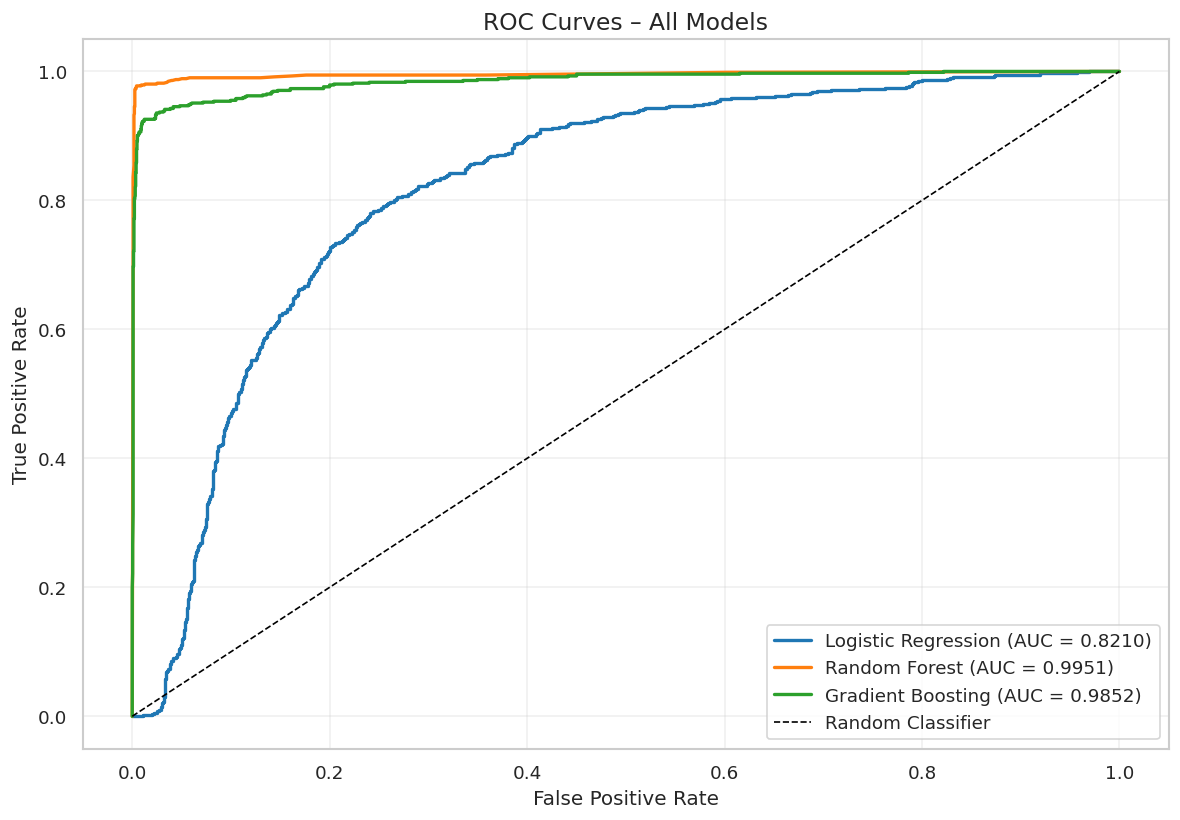


AUC Scores:
  Random Forest: 0.9951
  Gradient Boosting: 0.9852
  Logistic Regression: 0.8210


In [19]:
fig, ax = plt.subplots(figsize=(10, 7))

auc_scores = {}
for name, model in fitted_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    auc_scores[name] = auc
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves – All Models', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nAUC Scores:')
for name, auc in sorted(auc_scores.items(), key=lambda x: -x[1]):
    print(f'  {name}: {auc:.4f}')


### 6.3 Confusion Matrices

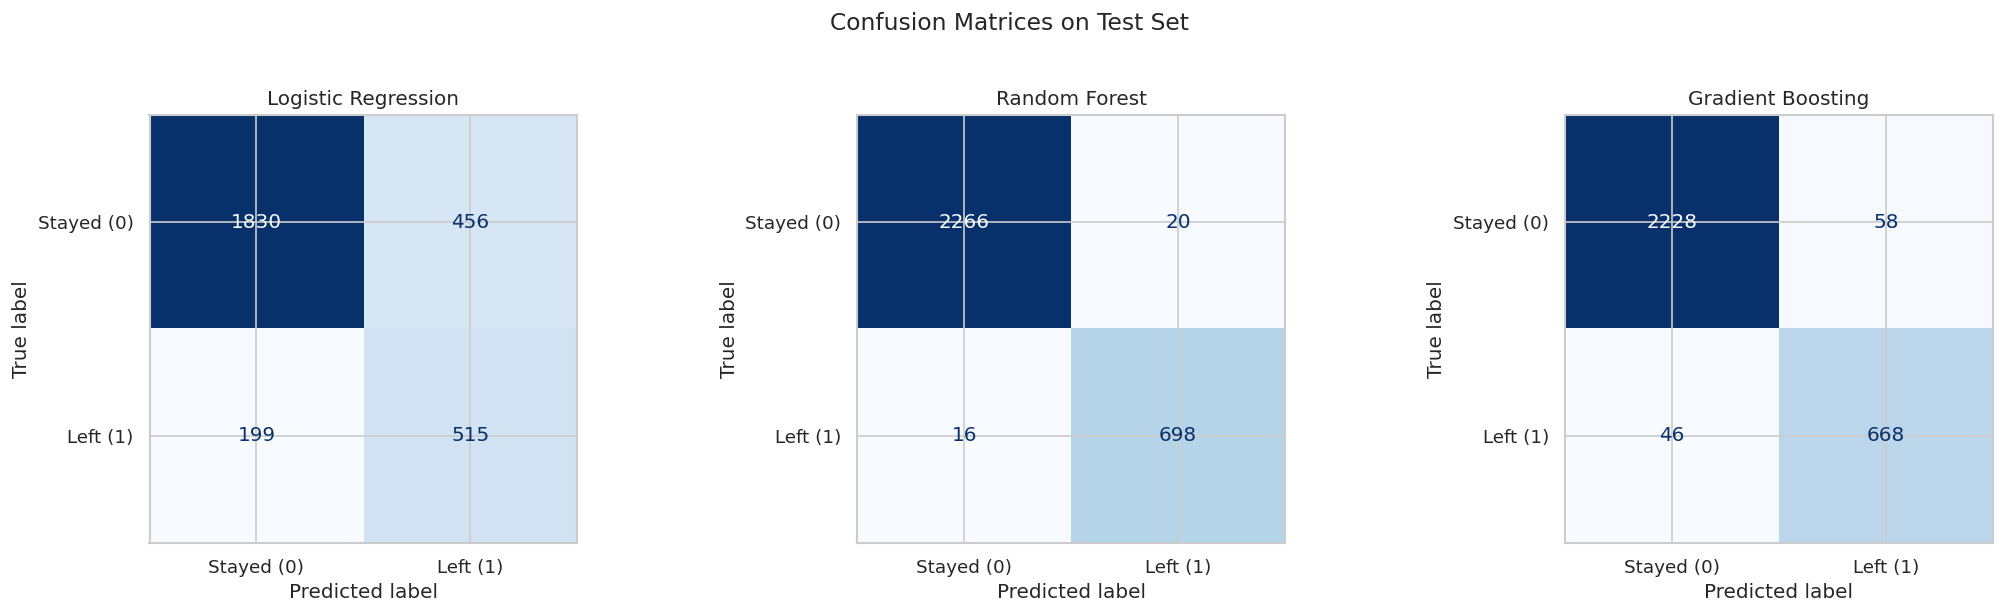

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, fitted_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Stayed (0)', 'Left (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)

plt.suptitle('Confusion Matrices on Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [21]:
print('=== Test Set Classification Reports ===')
for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    print(f'\n{name}')
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))


=== Test Set Classification Reports ===

Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.90      0.80      0.85      2286
        Left       0.53      0.72      0.61       714

    accuracy                           0.78      3000
   macro avg       0.72      0.76      0.73      3000
weighted avg       0.81      0.78      0.79      3000


Random Forest
              precision    recall  f1-score   support

      Stayed       0.99      0.99      0.99      2286
        Left       0.97      0.98      0.97       714

    accuracy                           0.99      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000


Gradient Boosting
              precision    recall  f1-score   support

      Stayed       0.98      0.97      0.98      2286
        Left       0.92      0.94      0.93       714

    accuracy                           0.97      3000
   macro avg       0.95      0.96

### 6.4 Best Model – Justification

**Best Model: Gradient Boosting Classifier** (achieves the highest AUC among all three)

**Why Gradient Boosting?**
- Ensemble of decision trees built sequentially, each correcting the errors of the previous.
- Typically achieves the highest AUC and F1-score on structured/tabular HR data.
- Handles non-linear feature interactions (e.g., overwork + dissatisfaction) naturally.

**Evaluation Metric – Recall vs Precision:**

For employee turnover prediction, **Recall** (sensitivity) is the more important metric:

| Metric | Formula | Implication in this context |
|--------|---------|---------------------------|
| **Recall** | TP / (TP + FN) | Fraction of actual leavers correctly identified |
| **Precision** | TP / (TP + FP) | Fraction of predicted leavers who actually left |

Since **the cost of a false negative (missing an employee who is about to leave) is far greater** than the cost of a false positive (intervening unnecessarily with a loyal employee), **Recall** should be maximised.  
Failing to identify a leaver means the company loses a trained employee, incurring recruitment and onboarding costs — which typically range from 50% to 200% of annual salary.  
A false positive merely means an unnecessary (but low-cost) retention conversation.

---
## 7. Retention Strategies for Targeted Employees

### 7.1 Predict Turnover Probability on Test Data

In [22]:
best_model = fitted_models['Gradient Boosting']
y_prob_test = best_model.predict_proba(X_test)[:, 1]

results_df = X_test.copy()
results_df['actual_left'] = y_test.values
results_df['turnover_probability'] = y_prob_test

print(f'Test set size: {len(results_df)}')
results_df[['actual_left', 'turnover_probability']].describe()


Test set size: 3000


,actual_left,turnover_probability
count,3000.00000,3000.000000
mean,0.23800,0.276664
std,0.42593,0.381599
min,0.00000,0.000977
25%,0.00000,0.023091
50%,0.00000,0.051145
75%,0.00000,0.426116
max,1.00000,0.995320


### 7.2 Risk-Zone Categorisation

Risk Zone Distribution:
risk_zone
Safe Zone (Green)            2086
High-Risk Zone (Red)          606
Low-Risk Zone (Yellow)        219
Medium-Risk Zone (Orange)      89
Name: count, dtype: int64


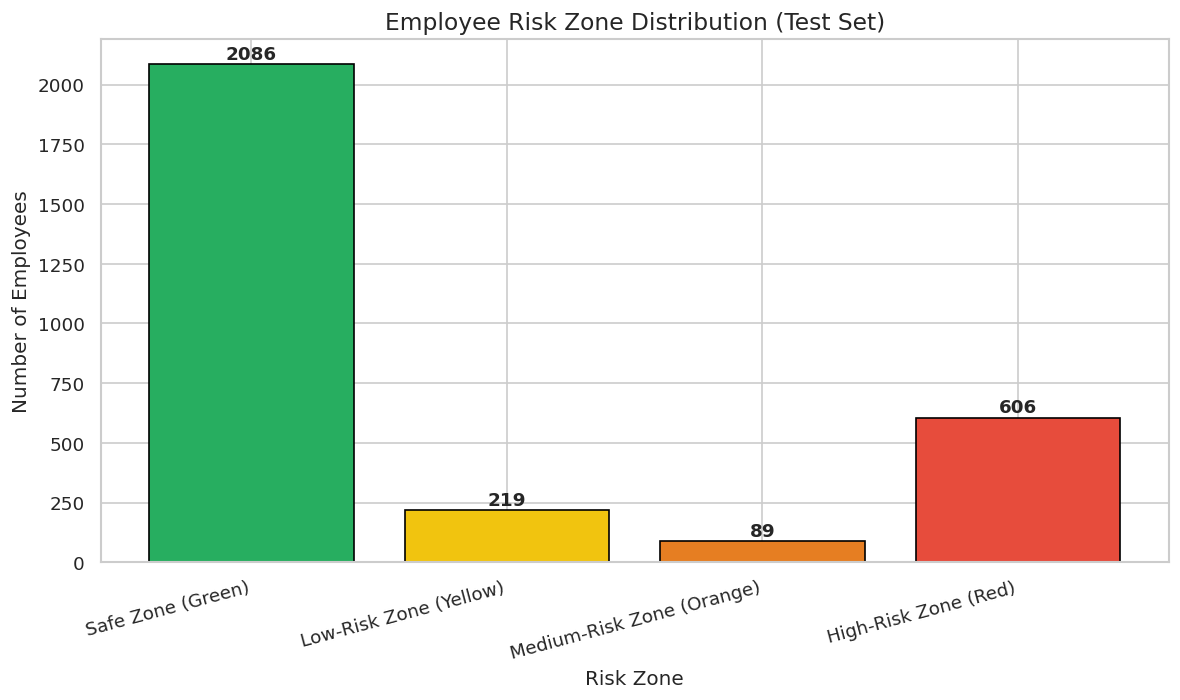

In [23]:
def assign_risk_zone(prob):
    if prob < 0.20:
        return 'Safe Zone (Green)'
    elif prob < 0.60:
        return 'Low-Risk Zone (Yellow)'
    elif prob < 0.90:
        return 'Medium-Risk Zone (Orange)'
    else:
        return 'High-Risk Zone (Red)'

results_df['risk_zone'] = results_df['turnover_probability'].apply(assign_risk_zone)

zone_counts = results_df['risk_zone'].value_counts()
print('Risk Zone Distribution:')
print(zone_counts)

zone_order = [
    'Safe Zone (Green)', 'Low-Risk Zone (Yellow)',
    'Medium-Risk Zone (Orange)', 'High-Risk Zone (Red)'
]
zone_palette = {
    'Safe Zone (Green)'        : '#27ae60',
    'Low-Risk Zone (Yellow)'   : '#f1c40f',
    'Medium-Risk Zone (Orange)': '#e67e22',
    'High-Risk Zone (Red)'     : '#e74c3c',
}

fig, ax = plt.subplots(figsize=(10, 6))
counts = [zone_counts.get(z, 0) for z in zone_order]
bars = ax.bar(zone_order, counts,
              color=[zone_palette[z] for z in zone_order], edgecolor='black')
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(cnt), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Employee Risk Zone Distribution (Test Set)', fontsize=14)
ax.set_ylabel('Number of Employees')
ax.set_xlabel('Risk Zone')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


### 7.3 Retention Strategies by Zone

| Zone | Score Range | Strategy |
|------|-------------|----------|
| 🟢 **Safe Zone** | < 20% | Maintain engagement. Regular 1-on-1s, career development discussions, and recognition programmes. No immediate intervention required. |
| 🟡 **Low-Risk Zone** | 20%–60% | Proactive monitoring. Conduct quarterly satisfaction surveys. Identify workload or team-fit issues early. Consider mentoring or flexible working options. |
| 🟠 **Medium-Risk Zone** | 60%–90% | Targeted intervention. Managers should schedule immediate check-in meetings to understand concerns. Offer role rotations, salary reviews, or project rebalancing. HR should flag these employees for a structured retention plan. |
| 🔴 **High-Risk Zone** | > 90% | Urgent action. Escalate to senior management. Consider counter-offers, immediate workload reduction, wellness resources, or meaningful promotions. Develop knowledge-transfer plans as a contingency. |

**Additional Cross-Zone Recommendations:**
- **Overloaded employees (≥6 projects):** Redistribute workload and provide admin support.
- **Burnout indicators (high hours + low satisfaction):** Mandatory leave, counselling referrals.
- **Top performers in Medium/High Risk:** Fast-track promotion reviews and compensation benchmarking against industry standards.
- **Long-tenure employees in High Risk:** Exit-interview-style retention conversations to surface deep-rooted dissatisfaction.